# Import libraries
All the libraries are imported here, those will not be imported later in the code

In [1]:
import os
import matplotlib.pyplot as plt 
import pyproj as pp
import numpy as np 
import xarray as xr 
import imageio.v2 as imageio
import pyproj

from bmi_topography import Topography 
from rasterio.warp import Resampling, calculate_default_transform, reproject 
from landlab import RasterModelGrid, imshow_grid 
from landlab.components import PriorityFloodFlowRouter 
from landlab.components import FastscapeEroder, FlowAccumulator, NormalFault, ChannelProfiler
from landlab.grid.create_network import network_grid_from_raster 
from landlab.plot.graph import plot_links, plot_nodes
from PIL import Image

%matplotlib inline

# Import and visualize DEM and fault trace

This is a DEM of the Eastern Alps and the fault trace of a ~28 km long composite fault

/opt/tljh/user/envs/ivy/lib/python3.13/site-packages/bmi_topography/topography.py:255: UserWarning: A CRS cannot be identified for these data. Grid units will be set to 'unknown'.
  warnings.warn(


grid: 1298 x 2226 = 2,889,348 nodes


<Figure size 640x480 with 0 Axes>

Fault trace in UTM33N: (229521.6, 5197214.2) -> (424816.2, 5154848.4)


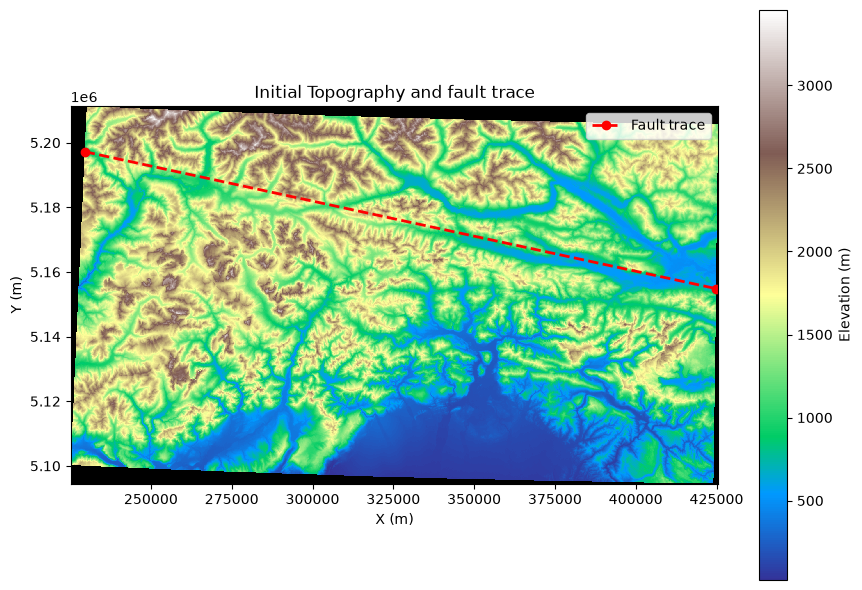

In [2]:
API_KEY = os.environ.get("OPENTOPOGRAPHY_API_KEY", "5555922bf1202c4030f232561cca617a") 
NODATA = -9999 
RES = 90  # m; ~native SRTMGL3. Use SRTMGL1 + RES=30 for finer (bigger download). 
UTM_CRS = "EPSG:32633"  # UTM 33N - bbox centre ~12.7E, zone 33 spans 12-18E 
MIN_CHANNEL_AREA = 50e6  # m^2 upstream area to start a channel; start high, lower for more detail 

# --- 1. download ----------------------------------------------------------- 

dem = Topography( 
    north=47.0, 
    south=46.0, 
    east=14.0194, 
    west=11.4505, 
    output_format="AAIGrid", 
    dem_type="SRTMGL3", 
    cache_dir=".bmi_topography", 
    api_key=API_KEY,  # fixed: your original had a leading space in the key string 
) 

dem.load() 

# --- 2. reproject WGS84 -> UTM --------------------------------------------- 

src_crs = "EPSG:4326" 
transform, nx, ny = calculate_default_transform( 
    src_crs, 
    UTM_CRS, 
    len(dem.da["x"]), 
    len(dem.da["y"]), 
    left=dem.bbox.west, 
    bottom=dem.bbox.south, 
    right=dem.bbox.east, 
    top=dem.bbox.north, 
    resolution=RES, 
) 

# cell-centre coords straight from the affine (row 0 = north edge) 
x_utm = transform.c + transform.a * (np.arange(nx) + 0.5) 
y_utm = transform.f + transform.e * (np.arange(ny) + 0.5) 

out = xr.DataArray( 
    np.empty((1, ny, nx), dtype="float32"), 
    dims=["band", "y", "x"], 
    coords={"band": [1], "y": y_utm, "x": x_utm}, 
) 

arr, _ = reproject( 
    dem.da, 
    out, 
    src_transform=dem.da.rio.transform(), 
    src_crs=src_crs, 
    src_nodata=dem.da.rio.nodata, 
    dst_transform=transform, 
    dst_crs=UTM_CRS, 
    dst_nodata=NODATA, 
    resampling=Resampling.nearest, 
) 
 
# --- 3. Landlab RasterModelGrid -------------------------------------------- 

grid = RasterModelGrid( 
    (ny, nx), 
    xy_spacing=RES, 
    xy_of_lower_left=(x_utm[0], y_utm[-1]),  # lower-left = last (southern) row 
    xy_axis_name=("X UTM33", "Y UTM33"), 
    xy_axis_units="m", 
) 

z = np.flipud(np.asarray(arr).squeeze()).ravel().astype(float)  # Landlab node 0 is SW corner 
grid.at_node["topographic__elevation"] = z 
grid.status_at_node[np.isclose(z, NODATA)] = grid.BC_NODE_IS_CLOSED 
print(f"grid: {ny} x {nx} = {grid.number_of_nodes:,} nodes") 

# --- 4. visualize the DEM --------------------------------------------------- 

fig, ax = plt.subplots(figsize=(8, 6)) 
imshow_grid( 
    grid, 
    "topographic__elevation", 
    plot_name="Topographic Elevation (UTM33)", 
    var_name="Elevation", 
    var_units="m", 
    cmap="terrain", 
    grid_units=("m", "m"), 
) 

plt.tight_layout() 
#plt.savefig("dem_elevation.png", dpi=150) 
plt.close(fig)

def decimal_to_dms(deg, is_lat): 
    hemi = ("N" if deg >= 0 else "S") if is_lat else ("E" if deg >= 0 else "W") 
    deg = abs(deg) 
    d = int(deg) 
    m_full = (deg - d) * 60 
    m = int(m_full) 
    s = (m_full - m) * 60 
    return f"{d}\u00b0{m:02d}'{s:04.1f}\"{hemi}" 

 
transformer = pyproj.Transformer.from_crs(UTM_CRS, "EPSG:4326", always_xy=True) 

# pick tick positions in UTM metres (5 ticks per axis is usually readable) 
x_ticks = np.linspace(x_utm.min(), x_utm.max(), 5) 
y_ticks = np.linspace(y_utm.min(), y_utm.max(), 5) 

# convert each axis's ticks to lon/lat, holding the other coordinate at the map's centre (since UTM->lonlat is not separable, this is an approximation good enough for tick labels, not exact per-point conversion) 

lon_ticks, _ = transformer.transform(x_ticks, np.full_like(x_ticks, y_utm.mean())) 
_, lat_ticks = transformer.transform(np.full_like(y_ticks, x_utm.mean()), y_ticks) 

ax.set_xticks(x_ticks) 
ax.set_xticklabels([decimal_to_dms(lon, is_lat=False) for lon in lon_ticks], rotation=30, ha="right") 
ax.set_yticks(y_ticks) 
ax.set_yticklabels([decimal_to_dms(lat, is_lat=True) for lat in lat_ticks]) 
ax.set_xlabel("Longitude") 
ax.set_ylabel("Latitude") 

plt.tight_layout() 
plt.show() 

# Add fault trace

V1 = [11.4505, 46.8734] 
V2 = [14.0194, 46.5430] 

transformer = pyproj.Transformer.from_crs("EPSG:4326", UTM_CRS, always_xy=True) 

x1_utm, y1_utm = transformer.transform(V1[0], V1[1]) 
x2_utm, y2_utm = transformer.transform(V2[0], V2[1]) 

print(f"Fault trace in UTM33N: ({x1_utm:.1f}, {y1_utm:.1f}) -> ({x2_utm:.1f}, {y2_utm:.1f})") 

z = grid.at_node["topographic__elevation"]
z_init = z.copy()

nf = NormalFault( 
    grid, 
    faulted_surface="topographic__elevation", 
    fault_trace={"x1": x1_utm, "y1": y1_utm, "x2": x2_utm, "y2": y2_utm}, 
    include_boundaries=True,
)

fig, ax = plt.subplots(figsize=(9, 6)) 
imshow_grid( 
    grid, 
    "topographic__elevation", 
    plot_name="Initial Topography and fault trace", 
    var_name="Elevation", 
    var_units="m", 
    cmap="terrain", 
    grid_units=("m", "m"), 
) 

ax.plot( 
    [x1_utm, x2_utm], 
    [y1_utm, y2_utm], 
    color="red", 
    linewidth=2, 
    linestyle="--", 
    marker="o", 
    markersize=6, 
    label="Fault trace", 
) 

ax.legend(loc="upper right") 
plt.tight_layout() 
plt.show()

# Add Erosion and Uplift

Here we define the input parameters for the model and do a gif of the first 10,000 years of erosion

In [3]:
import shutil
frame_dir = "frames"
if os.path.exists(frame_dir):
    shutil.rmtree(frame_dir)
os.makedirs(frame_dir, exist_ok=True)
frame_paths = []

/opt/tljh/user/envs/ivy/lib/python3.13/site-packages/landlab/graph/sort/sort.py:724: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  angle_of_spoke_at_hub = np.arctan2(dy, dx, where=spokes_at_hub != -1)


<Figure size 640x480 with 0 Axes>

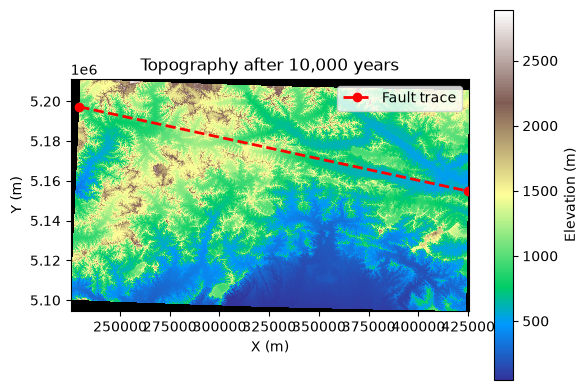

In [4]:
K = 0.0005  # stream power coefficient, bigger = streams erode more quickly
U = 0.0025  # uplift rate in meters per year
dt = 2000  # time step in years
frame_every = 1
elev_min, elev_max = 0, 3000

# Saves frames in a folder
frame_dir = "frames"
os.makedirs(frame_dir, exist_ok=True)

fr = FlowAccumulator(grid, flow_director="D8") 
fs = FastscapeEroder(grid, K_sp=K) 

frame_paths = []

def save_frame(step_index, time_years):
    fig, ax = plt.subplots(figsize=(8, 5))
    imshow_grid(
        grid,
        "topographic__elevation",
        cmap="terrain",
        colorbar_label="Elevation (m)",
        limits=(elev_min, elev_max),
    )
    ax.set_title(f"t = {time_years:,} years")
    fname = os.path.join(frame_dir, f"frame_{step_index:04d}.png")
    fig.savefig(fname, dpi=100)
    plt.close(fig)
    frame_paths.append(fname)
    ax.plot( 
    [x1_utm, x2_utm], 
    [y1_utm, y2_utm], 
    color="red", 
    linewidth=2, 
    linestyle="--", 
    marker="o", 
    markersize=6, 
    label="Fault trace", 
) 

ax.legend(loc="upper right") 
plt.tight_layout() 
plt.show()

#Initial frame (t = 0)
save_frame(0, 0)

for i in range(5):
    fr.run_one_step()
    fs.run_one_step(dt)
    z[grid.core_nodes] += U * dt

    #if (i + 1) % frame_every == 0:
        #save_frame(i + 1, (i + 1) * dt)

# plot the topography
# --- 4. visualize the DEM --------------------------------------------------- 

fig, ax = plt.subplots(figsize=(6, 4)) 
imshow_grid( 
    grid, 
    "topographic__elevation", 
    plot_name="Topography after 10,000 years", 
    var_name="Elevation", 
    var_units="m", 
    cmap="terrain", 
    grid_units=("m", "m"), 
) 

ax.plot( 
    [x1_utm, x2_utm], 
    [y1_utm, y2_utm], 
    color="red", 
    linewidth=2, 
    linestyle="--", 
    marker="o", 
    markersize=6, 
    label="Fault trace", 
) 

ax.legend(loc="upper right") 
plt.tight_layout() 
plt.show()

# Assemble the frames into a video
output_video = "topo_evolution_erosion.mp4"
fps = 5  # frames per second

output_gif = "topo_evolution_erosion.gif"
with imageio.get_writer(output_gif, mode="I", fps=fps) as writer:
     for path in frame_paths:
         img = Image.open(path)
         img = img.resize((img.width // 2, img.height // 2))  # halve resolution
         img = img.convert("P", palette=Image.ADAPTIVE, colors=128)  # reduce colors
         writer.append_data(np.array(img.convert("RGB")))

print(f"GIF saved in: {output_gif}")

from IPython.display import Image as IPImage
IPImage(output_gif)

print(f"Video saved in: {output_video}")

/opt/tljh/user/envs/ivy/lib/python3.13/site-packages/landlab/graph/sort/sort.py:724: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  angle_of_spoke_at_hub = np.arctan2(dy, dx, where=spokes_at_hub != -1)


<Figure size 640x480 with 0 Axes>

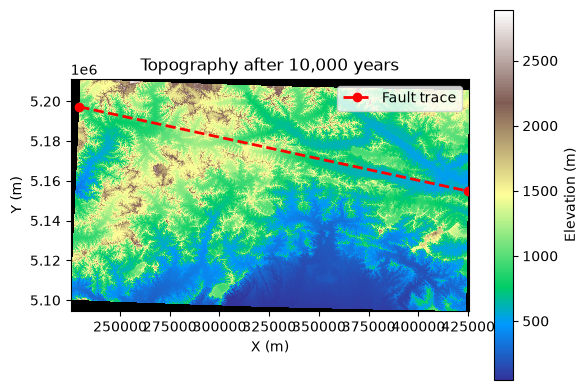

In [4]:
K = 0.0005  # stream power coefficient, bigger = streams erode more quickly
U = 0.0025  # uplift rate in meters per year
dt = 2000  # time step in years
frame_every = 1
elev_min, elev_max = 0, 3000

# Saves frames in a folder
frame_dir = "frames"
os.makedirs(frame_dir, exist_ok=True)

fr = FlowAccumulator(grid, flow_director="D8") 
fs = FastscapeEroder(grid, K_sp=K) 

frame_paths = []

def save_frame(step_index, time_years):
    fig, ax = plt.subplots(figsize=(8, 5))
    imshow_grid(
        grid,
        "topographic__elevation",
        cmap="terrain",
        colorbar_label="Elevation (m)",
        limits=(elev_min, elev_max),
    )
    ax.set_title(f"t = {time_years:,} years")
    fname = os.path.join(frame_dir, f"frame_{step_index:04d}.png")
    fig.savefig(fname, dpi=100)
    plt.close(fig)
    frame_paths.append(fname)
    ax.plot( 
    [x1_utm, x2_utm], 
    [y1_utm, y2_utm], 
    color="red", 
    linewidth=2, 
    linestyle="--", 
    marker="o", 
    markersize=6, 
    label="Fault trace", 
) 

ax.legend(loc="upper right") 
plt.tight_layout() 
plt.show()

#Initial frame (t = 0)
save_frame(0, 0)

for i in range(5):
    fr.run_one_step()
    fs.run_one_step(dt)
    z[grid.core_nodes] += U * dt

    #if (i + 1) % frame_every == 0:
        #save_frame(i + 1, (i + 1) * dt)

# plot the topography
# --- 4. visualize the DEM --------------------------------------------------- 

fig, ax = plt.subplots(figsize=(6, 4)) 
imshow_grid( 
    grid, 
    "topographic__elevation", 
    plot_name="Topography after 10,000 years", 
    var_name="Elevation", 
    var_units="m", 
    cmap="terrain", 
    grid_units=("m", "m"), 
) 

ax.plot( 
    [x1_utm, x2_utm], 
    [y1_utm, y2_utm], 
    color="red", 
    linewidth=2, 
    linestyle="--", 
    marker="o", 
    markersize=6, 
    label="Fault trace", 
) 

ax.legend(loc="upper right") 
plt.tight_layout() 
plt.show()

# Assemble the frames into a video
output_video = "topo_evolution_erosion.mp4"
fps = 5  # frames per second

output_gif = "topo_evolution_erosion.gif"
with imageio.get_writer(output_gif, mode="I", fps=fps) as writer:
     for path in frame_paths:
         img = Image.open(path)
         img = img.resize((img.width // 2, img.height // 2))  # halve resolution
         img = img.convert("P", palette=Image.ADAPTIVE, colors=128)  # reduce colors
         writer.append_data(np.array(img.convert("RGB")))

print(f"GIF saved in: {output_gif}")

from IPython.display import Image as IPImage
IPImage(output_gif)

print(f"Video saved in: {output_video}")

# Add faulting event

Displacement = 1000 m

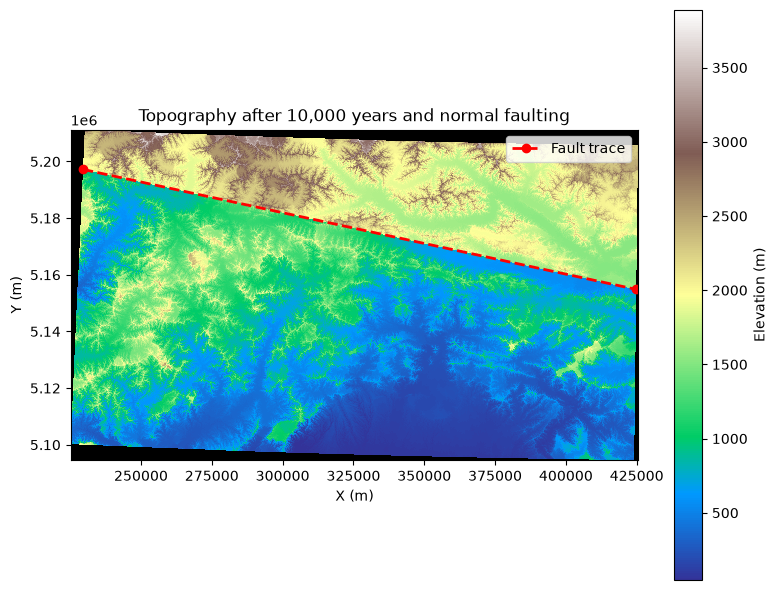

In [5]:
# Earthquake with 200 m displacement 
nf.run_one_earthquake(dz=1000)

# plot the  topography
fig, ax = plt.subplots(figsize=(8, 6)) 
imshow_grid( 
    grid, 
    "topographic__elevation", 
    plot_name="Topography after 10,000 years and normal faulting", 
    var_name="Elevation", 
    var_units="m", 
    cmap="terrain", 
    grid_units=("m", "m"), 
) 

ax.plot( 
    [x1_utm, x2_utm], 
    [y1_utm, y2_utm], 
    color="red", 
    linewidth=2, 
    linestyle="--", 
    marker="o", 
    markersize=6, 
    label="Fault trace", 
) 

ax.legend(loc="upper right") 
plt.tight_layout() 
plt.show()

# Faulting, Erosion, and Uplift

Here the video of the simultaneous events is saved, stored, and shown

GIF salvata in: topo_evolution_earthquake.gif
Video salvato in: topo_evolution_earthquake.mp4


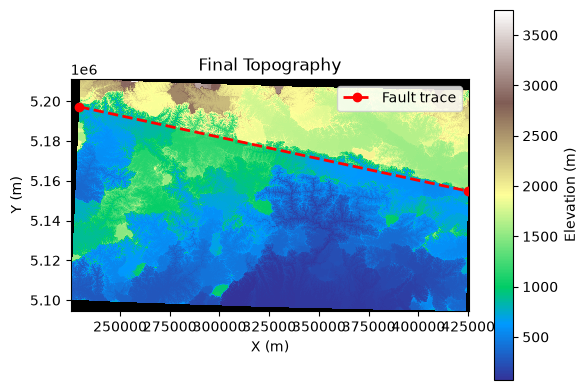

In [6]:
n_steps = 5            # numero di time step totali
frame_every = 1         # salva un frame ogni N step (1 = ogni step)
elev_min, elev_max = 0, 3000   # scala colore fissa, adattala ai tuoi valori

# Cartella dove salvare i frame
frame_dir = "frames_earthquake"
os.makedirs(frame_dir, exist_ok=True)

frame_paths = []

def save_frame(step_index, time_years):
    """Save current topography"""
    fig, ax = plt.subplots(figsize=(6, 4))
    imshow_grid(
        grid,
        "topographic__elevation",
        cmap="terrain",
        colorbar_label="Elevation (m)",
        limits=(elev_min, elev_max),
    )
    ax.set_title(f"t = {time_years:,} years")
    fname = os.path.join(frame_dir, f"frame_{step_index:04d}.png")
    fig.savefig(fname, dpi=100)   # <-- niente bbox_inches="tight"
    plt.close(fig)
    frame_paths.append(fname)

# Frame iniziale (t = 0)
save_frame(0, 0)

# Run this model again for 20 1000-year timesteps (20_000 years).
for i in range(5):
   fr.run_one_step()
   fs.run_one_step(dt)
   z[grid.core_nodes] += U * dt
    
   if (i + 1) % frame_every == 0:
        save_frame(i + 1, (i + 1) * dt)

output_video = "topo_evolution_earthquake.mp4"
fps = 5  # fotogrammi al secondo (regola la velocità del video)

output_gif = "topo_evolution_earthquake.gif"
with imageio.get_writer(output_gif, mode="I", fps=fps) as writer:
    for path in frame_paths:
        img = imageio.imread(path)
        writer.append_data(img)

print(f"GIF salvata in: {output_gif}")

from IPython.display import Image as IPImage
IPImage(output_gif)

print(f"Video salvato in: {output_video}")
    
# plot the  topography
fig, ax = plt.subplots(figsize=(6, 4)) 
imshow_grid( 
    grid, 
    "topographic__elevation", 
    plot_name="Final Topography", 
    var_name="Elevation", 
    var_units="m", 
    cmap="terrain", 
    grid_units=("m", "m"), 
) 

ax.plot( 
    [x1_utm, x2_utm], 
    [y1_utm, y2_utm], 
    color="red", 
    linewidth=2, 
    linestyle="--", 
    marker="o", 
    markersize=6, 
    label="Fault trace", 
) 

ax.legend(loc="upper right") 
plt.tight_layout() 
plt.show()